# GNN Training

In [1]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', '..')))

from gnn_project.config import Config
from gnn_project.training.train_utils import train_or_load_model, load_data

## GNN Model

In [2]:
config = Config(
    ml_data_dir='/Users/hoda_hamdy/Documents/Projects/fleetpy/FleetPy/gnn_project/data',
    experiment_name='gnn_v1',
    sim_start=0,
    sim_end=2*60*60,
    load_saved_model=True,
    overwrite_data=True,
    log_level='DEBUG',
)

In [10]:
import logging
logging.getLogger().setLevel(config.log_level)

In [11]:
data, masks = load_data(config)

DEBUG:gnn_project.dataloaders.gnn_dataloader:Total number of scenarios: 3
DEBUG:gnn_project.dataloaders.gnn_dataloader:Train size: 1, Val size: 1, Test size: 1
Normalizing scenarios:   0%|          | 0/3 [00:00<?, ?it/s]DEBUG:gnn_project.dataloaders.gnn_dataloader:Continuous features: ['o_lat', 'o_lon', 'd_lat', 'd_lon', 'rq_time', 'tw_pe', 'tw_pl', 'direct_tt', 'direct_td', 'max_trip_time', 'time_until_earliest', 'time_until_latest', 'time_window_width', 'time_window_urgency', 'request_age', 'manhattan_distance', 'route_directness', 'origin_dest_bearing', 'nearby_requests', 'nearby_vehicles', 'demand_supply_ratio', 'in_degree_total', 'out_degree_total', 'in_degree_from_requests', 'out_degree_to_requests', 'in_degree_from_vehicles', 'out_degree_to_vehicles', 'request_vehicle_in_ratio', 'request_vehicle_out_ratio', 'clustering_coeff', 'nx_combined_degree_centrality', 'nx_combined_betweenness_centrality', 'nx_combined_closeness_centrality', 'nx_combined_pagerank', 'nx_rr_degree_centralit

In [12]:
model, trainer = train_or_load_model(config, data, masks)

INFO:gnn_project.training.train_utils:Loading model from /Users/hoda_hamdy/Documents/Projects/fleetpy/FleetPy/gnn_project/data/models/gnn_v1/best_model.pt


## Visualization

In [ ]:
from gnn_project.analysis.plots import visualize_graph
from gnn_project.training.train_utils import get_edge_predictions

graph_idx = 5  # Index of the graph to visualize
predictions = get_edge_predictions(data[graph_idx], model, device='cpu')
visualize_graph(data, graph_idx=graph_idx, predictions=predictions, device=config.device, only_new_requests=True);

ERROR:gnn_project.analysis.plots:Error during prediction: mat1 and mat2 shapes cannot be multiplied (1x44 and 43x32)


ValueError: Could not get predictions from model

ERROR:gnn_project.analysis.plots:Error during prediction: mat1 and mat2 shapes cannot be multiplied (1x44 and 43x32)
ERROR:gnn_project.analysis.plots:Error during prediction: mat1 and mat2 shapes cannot be multiplied (1x44 and 43x32)
ERROR:gnn_project.analysis.plots:Error during prediction: mat1 and mat2 shapes cannot be multiplied (1x44 and 43x32)
ERROR:gnn_project.analysis.plots:Error during prediction: mat1 and mat2 shapes cannot be multiplied (1x44 and 43x32)
ERROR:gnn_project.analysis.plots:Error during prediction: mat1 and mat2 shapes cannot be multiplied (1x44 and 43x32)
ERROR:gnn_project.analysis.plots:Error during prediction: mat1 and mat2 shapes cannot be multiplied (1x44 and 43x32)
ERROR:gnn_project.analysis.plots:Error during prediction: mat1 and mat2 shapes cannot be multiplied (1x44 and 43x32)
ERROR:gnn_project.analysis.plots:Error during prediction: mat1 and mat2 shapes cannot be multiplied (1x44 and 43x32)
ERROR:gnn_project.analysis.plots:Error during prediction: mat1 a

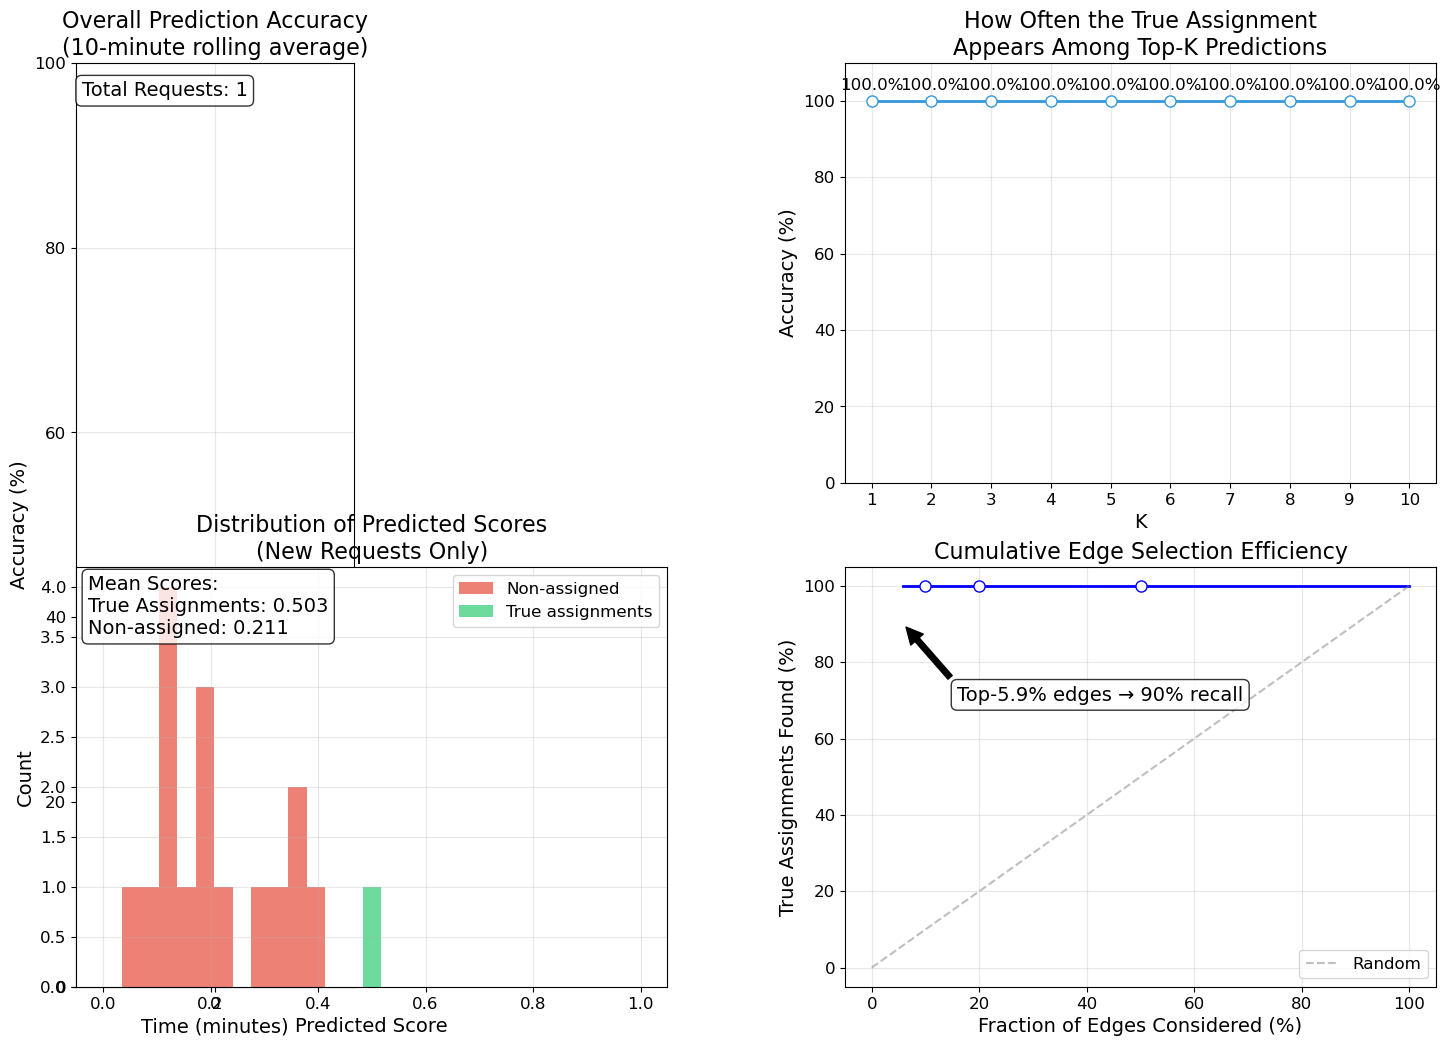

In [ ]:
# Analyze model performance over a range of graphs
from gnn_project.analysis.plots import analyze_model_performance
import matplotlib.pyplot as plt
start_idx = 480  # Starting graph index
num_graphs = 240  # Number of graphs to analyze

# TODO split to separate plots
# TODO get all graph predictions at once
predictions = [get_edge_predictions(data[i], model, device='cpu') for i in range(start_idx, start_idx + num_graphs)]
fig = analyze_model_performance(data, start_idx, num_graphs, predictions, config.device)
if fig:
    plt.show()